# Building the final models
---
### Models to build:
- Ridge (the best model)
- LGBMRegressor



In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor

import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.base import BaseEstimator, RegressorMixin, clone
import joblib

In [6]:
def regression_metrics(y_true, y_pred):
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 3)
    mae = round(mean_absolute_error(y_true, y_pred), 3)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denom
    return {'rmse':rmse, 'mae':mae, 'wape':round(wape, 3)}

In [7]:
df = pd.read_csv("dados/CompactedData.csv")
df["Date"] = pd.to_datetime(df.Date)
df.set_index('Date', inplace=True)
df.head(3)

,UNETOT_PT_ea-md,UNEO25_PT_ea-md,UNEU25_PT_ea-md,REER42_PT_ea-md,LTIRT_PT_ea-md,IPMN_PT_ea-md,IPCAG_PT_ea-md,IPCOG_PT_ea-md,IPDCOG_PT_ea-md,IPNDCOG_PT_ea-md,...,OILPRICEx_fred-md,CUSR0000SAC_fred-md,PCEPI_fred-md,S&P 500_fred-md,epu_pt_epu,unemployment_up_15_unemployment,exchange_exchange,PPIPT_ppi,inflation_target,OILPRICEx_fred-md_Eur
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,5.6,4.4,12.7,96.14621,5.81,123.5,191.3,118.0,129.6,116.5,...,27.18,146.7,72.961,1425.59,107.096201,5.6,0.9791,21.5,2.1,27.760188
2000-02-01,5.4,4.1,13.0,95.12462,5.78,122.7,177.4,119.8,131.1,118.2,...,29.35,147.6,73.191,1388.87,105.539878,5.4,0.9714,21.9,1.8,30.214124
2000-03-01,5.3,4.0,12.4,94.49293,5.61,116.5,164.6,116.5,124.8,115.3,...,29.89,149.1,73.505,1442.21,68.844150,5.3,0.9553,21.2,1.5,31.288600


In [8]:
def outliers(X, level=0):
    """
        - X: variável onde se verifica os outliers
        - level: default 0 - outliers não severos; 1 outliers severos
    """

    assert level in (0, 1), "Level invalido - valores aceites (0, 1)"

    out_level = (1.5, 3)
    Q1 = X.quantile(.25)
    Q3 = X.quantile(.75)
    IQR = Q3 - Q1

    left = Q1 - out_level[level] * IQR
    right = Q3 + out_level[level] * IQR

    return (left, right)

In [9]:
ridge_vars_model = [
    'PCEPI_fred-md', 'HICPOV_PT_ea-md', 'HICPNEF_PT_ea-md',
    'HICPNG_PT_ea-md', 'PPIPT_ppi', 'HICPSV_PT_ea-md',
    'CCI_PT_ea-md', 'EXPGS_PT_ea-qd', 'epu_pt_epu'
]

lgbm_vars_model = [
    'epu_pt_epu', 'ULCIN_PT_ea-qd', 'EXPGS_PT_ea-qd', 'IMPGS_PT_ea-qd',
    'CCI_PT_ea-md', 'GDP_PT_ea-qd', 'UNETOT_PT_ea-md', 'PPIPT_ppi'
]

data = df[ridge_vars_model + ['inflation_target']].copy()
data_lgbm = df[lgbm_vars_model + ['inflation_target']].copy()
data.head(3)


,PCEPI_fred-md,HICPOV_PT_ea-md,HICPNEF_PT_ea-md,HICPNG_PT_ea-md,PPIPT_ppi,HICPSV_PT_ea-md,CCI_PT_ea-md,EXPGS_PT_ea-qd,epu_pt_epu,inflation_target
Date,,,,,,,,,,
2000-01-01,72.961,57.50,62.77,42.21,21.5,49.68,102.3880,NaN,107.096201,2.1
2000-02-01,73.191,57.34,62.51,42.29,21.9,49.94,102.2470,NaN,105.539878,1.8
2000-03-01,73.505,57.45,62.67,42.41,21.2,50.10,101.9521,10151.5,68.844150,1.5


In [10]:
variables = dict()

for col in data.columns:
    left, right = outliers(data[col])
    variables[col] = data.loc[(data[col] < left) | (data[col] > right)].shape[0]

pd.Series(variables).sort_values(ascending=False)

PPIPT_ppi           25
inflation_target    12
HICPNEF_PT_ea-md     9
epu_pt_epu           5
HICPOV_PT_ea-md      4
CCI_PT_ea-md         1
PCEPI_fred-md        0
HICPNG_PT_ea-md      0
HICPSV_PT_ea-md      0
EXPGS_PT_ea-qd       0
dtype: int64

In [11]:
def build_transformer(dataframe, random_state=322):
    variables = dict()

    for col in dataframe.columns:
        left, right = outliers(dataframe[col])
        variables[col] = dataframe.loc[(dataframe[col] < left) | (dataframe[col] > right)].shape[0]

    out_variables = pd.Series(variables).sort_values(ascending=False)
    cols_quantile = [col for col in out_variables[out_variables > 0].index if col != 'inflation_target']
    cols_standard = out_variables[out_variables == 0].index.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ('std', StandardScaler(), cols_standard),
            ('quantile', QuantileTransformer(
                n_quantiles=min(100, dataframe.shape[0]),
                output_distribution='normal',
                random_state=random_state,
            ), cols_quantile)
        ],
        remainder='passthrough'
    )

    transformer = preprocessor.fit(dataframe)
    cols_out = cols_standard + cols_quantile + [
        col for col in dataframe.columns if col not in cols_standard + cols_quantile
    ]

    return transformer, cols_out, out_variables


transformer_ridge, cols_out_ridge, out_variables_ridge = build_transformer(data)
transformer_lgbm, cols_out_lgbm, out_variables_lgbm = build_transformer(data_lgbm)

transformer = transformer_ridge
cols_out = cols_out_ridge


In [12]:
df_transformed = pd.DataFrame(transformer.transform(data), columns=cols_out)
df_transformed.index = data.index
df_transformed.head()


,PCEPI_fred-md,HICPNG_PT_ea-md,HICPSV_PT_ea-md,EXPGS_PT_ea-qd,PPIPT_ppi,HICPNEF_PT_ea-md,epu_pt_epu,HICPOV_PT_ea-md,CCI_PT_ea-md,inflation_target
Date,,,,,,,,,,
2000-01-01,-1.559557,-1.841826,-1.936890,NaN,2.152479,-2.681933,0.430727,-2.873431,5.199338,2.1
2000-02-01,-1.543606,-1.837269,-1.915842,NaN,2.322575,-5.199338,0.370961,-5.199338,2.332470,1.8
2000-03-01,-1.521828,-1.830433,-1.902889,-1.369928,2.056568,-2.840485,-1.159841,-2.989809,1.640603,1.5
2000-04-01,-1.526059,-1.699416,-1.886699,NaN,1.841348,-2.365248,-1.111979,-2.344882,1.378119,2.1
2000-05-01,-1.521828,-1.691441,-1.855936,NaN,1.747999,-2.119199,-0.725246,-2.203159,1.221062,2.5


In [13]:
joblib.dump(transformer_ridge, 'models/standardize_features.pkl')
joblib.dump(transformer_lgbm, 'models/standardize_features_lgbm.pkl')


['models/standardize_features_lgbm.pkl']

In [15]:
cols_out_lgbm

['EXPGS_PT_ea-qd',
 'IMPGS_PT_ea-qd',
 'UNETOT_PT_ea-md',
 'PPIPT_ppi',
 'GDP_PT_ea-qd',
 'ULCIN_PT_ea-qd',
 'epu_pt_epu',
 'CCI_PT_ea-md',
 'inflation_target']

In [14]:
cols_out

['PCEPI_fred-md',
 'HICPNG_PT_ea-md',
 'HICPSV_PT_ea-md',
 'EXPGS_PT_ea-qd',
 'PPIPT_ppi',
 'HICPNEF_PT_ea-md',
 'epu_pt_epu',
 'HICPOV_PT_ea-md',
 'CCI_PT_ea-md',
 'inflation_target']

In [20]:
from FinalPipeline import *
from FinalPipeline import prepare_dataset as DataPipeline

In [21]:
RANDOM_STATE = 322

data_treated = DataPipeline(data, treat_outliers=True, create_lags=True)['prepared_data'].dropna()
X = data_treated.drop('inflation_target', axis=1)
y = data_treated['inflation_target']

clf1 = Ridge(random_state=RANDOM_STATE)
clf1.fit(X, y)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,322


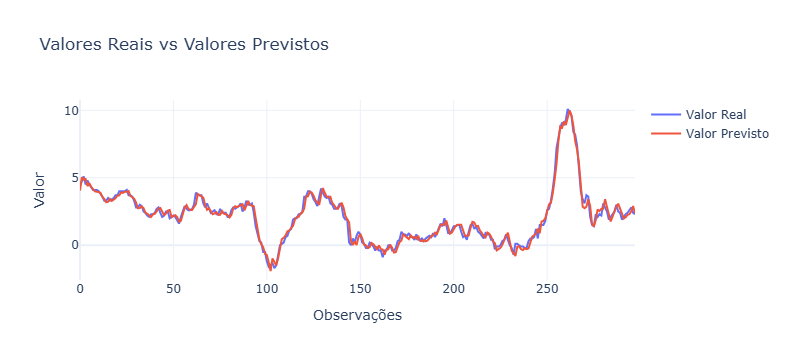

In [34]:
import plotly.graph_objects as go
import numpy as np

# Valores reais
y_real = y

# Valores previstos
y_pred = clf1.predict(X)

# Criar eixo temporal/index
x_axis = np.arange(len(y_real))

# Construir gráfico
fig = go.Figure()

# Linha dos valores reais
fig.add_trace(
    go.Scatter(
        x=x_axis,
        y=y_real,
        mode='lines',
        name='Valor Real'
    )
)

# Linha dos valores previstos
fig.add_trace(
    go.Scatter(
        x=x_axis,
        y=y_pred,
        mode='lines',
        name='Valor Previsto'
    )
)

# Layout
fig.update_layout(
    title='Valores Reais vs Valores Previstos',
    xaxis_title='Observações',
    yaxis_title='Valor',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

In [41]:
class InflationModel(BaseEstimator, RegressorMixin):

    def __init__(
        self,
        model=None,
        treat_outliers=True,
        create_lags=True,
        pipeline_model_type='ridge',
        drop_pipeline_columns=None,
    ):
        self.model = model if model is not None else Ridge()

        self.target_col = 'inflation_target'
        self.target_lag_col = 'inflation_target_lag_1'

        self.treat_outliers = treat_outliers
        self.create_lags = create_lags
        self.pipeline_model_type = pipeline_model_type
        self.drop_pipeline_columns = list(drop_pipeline_columns or [])

    def _prepare_data(self, data, dropna=False):
        prepared = DataPipeline(
            data,
            treat_outliers=self.treat_outliers,
            create_lags=self.create_lags,
            model_type=self.pipeline_model_type,
        )['prepared_data']
        prepared = prepared.drop(columns=self.drop_pipeline_columns, errors='ignore')
        return prepared.dropna() if dropna else prepared

    def _build_features(self, prepared):
        return prepared.drop(columns=[self.target_col], errors='ignore')

    def fit(self, data, y=None):
        self.train_data_ = data.copy()
        prepared = self._prepare_data(data, dropna=True)

        X = self._build_features(prepared)
        y = prepared[self.target_col]

        self.model_ = clone(self.model)
        self.model_.fit(X, y)
        self.feature_names_ = X.columns

        return self

    def predict(self, data):
        prepared = self._prepare_data(data)
        X = self._build_features(prepared)[self.feature_names_]
        return self.model_.predict(X.dropna(axis=0))

    def forecast(self, future_data):
        history = self.train_data_.copy()
        forecasts = []

        for idx in future_data.index:
            history = pd.concat([history, future_data.loc[[idx]]])
            prepared = self._prepare_data(history)
            current_row = prepared.iloc[[-1]]
            X = self._build_features(current_row)[self.feature_names_]

            pred = self.model_.predict(X)[0]
            forecasts.append(pred)
            history.loc[idx, self.target_col] = pred

        return pd.Series(forecasts, index=future_data.index, name='forecast')

    @property
    def explainability_(self):
        if hasattr(self.model_, 'coef_'):
            return pd.Series(self.model_.coef_, index=self.feature_names_)

        if hasattr(self.model_, 'feature_importances_'):
            return pd.Series(
                self.model_.feature_importances_,
                index=self.feature_names_
            ).sort_values(ascending=False)

        raise AttributeError('Modelo não suporta explicabilidade.')


In [42]:
model_ridge = InflationModel(
    model=Ridge(random_state=RANDOM_STATE),
    treat_outliers=True,
    create_lags=True,
    pipeline_model_type='ridge',
    drop_pipeline_columns=['epu_pt_epu', 'HICPSV_PT_ea-md'],
)

model_ridge.fit(data)

# preds = model_ridge.predict(data_test)


,model,Ridge(random_state=322)
,treat_outliers,True
,create_lags,True
,pipeline_model_type,'ridge'
,drop_pipeline_columns,"['epu_pt_epu', 'HICPSV_PT_ea-md']"
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'


In [43]:
model_ridge.explainability_

PCEPI_fred-md              0.475429
HICPOV_PT_ea-md            0.776956
HICPNEF_PT_ea-md           0.503434
HICPNG_PT_ea-md            0.038717
PPIPT_ppi                  0.099665
CCI_PT_ea-md               0.010926
EXPGS_PT_ea-qd             0.053208
HICPOV_PT_ea-md_lag_12    -0.862070
HICPNEF_PT_ea-md_lag_12   -0.777517
HICPNG_PT_ea-md_lag_12    -0.062975
PPIPT_ppi_lag_1           -0.140865
HICPSV_PT_ea-md_lag_12    -0.195697
epu_pt_epu_lag_6           0.023428
inflation_target_lag_1     0.847059
dtype: float64

In [44]:
future_df_ridge = pd.DataFrame({
    'PCEPI_fred-md':        list(range(100, 124)),
    'HICPOV_PT_ea-md':      list(range(200, 224)),
    'HICPNEF_PT_ea-md':     list(range(300, 324)),
    'HICPNG_PT_ea-md':      list(range(400, 424)),
    'PPIPT_ppi':            list(range(500, 524)),
    'HICPSV_PT_ea-md':      list(range(600, 624)),
    'CCI_PT_ea-md':         list(range(700, 724)),
    'EXPGS_PT_ea-qd':       list(range(800, 824)),
    'epu_pt_epu':           list(range(900, 924))
})

future_df_ridge['inflation_target'] = 0

last_3 = future_df_ridge.tail(3)

last_3.index = pd.date_range(
    start=data.index[-1] + pd.offsets.MonthBegin(),
    periods=len(last_3),
    freq='MS'
)

last_3.head()


,PCEPI_fred-md,HICPOV_PT_ea-md,HICPNEF_PT_ea-md,HICPNG_PT_ea-md,PPIPT_ppi,HICPSV_PT_ea-md,CCI_PT_ea-md,EXPGS_PT_ea-qd,epu_pt_epu,inflation_target
2025-11-01,121,221,321,421,521,621,721,821,921,0
2025-12-01,122,222,322,422,522,622,722,822,922,0
2026-01-01,123,223,323,423,523,623,723,823,923,0


In [45]:
model_ridge.forecast(last_3)

2025-11-01    38.195206
2025-12-01    67.856429
2026-01-01    93.121019
Freq: MS, Name: forecast, dtype: float64

In [46]:
joblib.dump(model_ridge, 'models/ridge_model.pkl')

['models/ridge_model.pkl']

In [47]:
model_lgbm = InflationModel(
    model=LGBMRegressor(
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
    treat_outliers=True,
    create_lags=True,
    pipeline_model_type='lgbm',
)

model_lgbm.fit(data_lgbm)


,model,"LGBMRegressor...2, verbose=-1)"
,treat_outliers,True
,create_lags,True
,pipeline_model_type,'lgbm'
,drop_pipeline_columns,[]
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000


In [48]:
model_lgbm.explainability_

inflation_target_lag_1    140
IMPGS_PT_ea-qd            136
IMPGS_PT_ea-qd_lag_3       97
IMPGS_PT_ea-qd_lag_2       80
PPIPT_ppi_lag_10           59
PPIPT_ppi                  49
UNETOT_PT_ea-md            48
PPIPT_ppi_lag_6            43
EXPGS_PT_ea-qd             40
PPIPT_ppi_lag_7            38
PPIPT_ppi_lag_9            29
PPIPT_ppi_lag_8            29
PPIPT_ppi_lag_2            26
PPIPT_ppi_lag_1            25
PPIPT_ppi_lag_4            25
epu_pt_epu                 24
epu_pt_epu_lag_8           23
GDP_PT_ea-qd_lag_5         22
PPIPT_ppi_lag_3            21
CCI_PT_ea-md               21
GDP_PT_ea-qd_lag_4         20
GDP_PT_ea-qd_lag_2         19
ULCIN_PT_ea-qd             17
GDP_PT_ea-qd               17
GDP_PT_ea-qd_lag_1         16
epu_pt_epu_lag_7           15
epu_pt_epu_lag_6           14
GDP_PT_ea-qd_lag_3         12
dtype: int32

In [49]:
future_df_lgbm = pd.DataFrame({
    'epu_pt_epu':         list(range(900, 924)),
    'ULCIN_PT_ea-qd':     list(range(950, 974)),
    'EXPGS_PT_ea-qd':     list(range(800, 824)),
    'IMPGS_PT_ea-qd':     list(range(1100, 1124)),
    'CCI_PT_ea-md':       list(range(700, 724)),
    'GDP_PT_ea-qd':       list(range(1000, 1024)),
    'UNETOT_PT_ea-md':    list(range(1200, 1224)),
    'PPIPT_ppi':          list(range(500, 524)),
})

future_df_lgbm['inflation_target'] = 0

last_3_lgbm = future_df_lgbm.tail(3)
last_3_lgbm.index = pd.date_range(
    start=data_lgbm.index[-1] + pd.offsets.MonthBegin(),
    periods=len(last_3_lgbm),
    freq='MS'
)

model_lgbm.forecast(last_3_lgbm)


C:\Users\josev\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log

C:\Users\josev\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log

C:\Users\josev\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log

C:\Users\josev\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log

C:\Users\josev\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log

C:\Users\josev\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

invalid value encountered in log



2025-11-01    2.904018
2025-12-01    3.060412
2026-01-01    4.430341
Freq: MS, Name: forecast, dtype: float64

In [50]:
joblib.dump(model_lgbm, 'models/lgbm_model.pkl')

['models/lgbm_model.pkl']